In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#2e3148',
    'axes.labelcolor'  : '#c9d1d9',
    'text.color'       : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'grid.color'       : '#21262d',
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlecolor'  : '#e6edf3',
})

PROC_DIR = '../data/processed'
VIZ_DIR  = '../visuals'
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(VIZ_DIR,  exist_ok=True)

accounts      = pd.read_csv(f'{PROC_DIR}/accounts_clean.csv',      parse_dates=['signup_date'])
subscriptions = pd.read_csv(f'{PROC_DIR}/subscriptions_clean.csv', parse_dates=['start_date','end_date'])

print(f'Accounts: {len(accounts):,} | Subscriptions: {len(subscriptions):,}')

Accounts: 500 | Subscriptions: 5,000


In [22]:
accounts['cohort_month'] = accounts['signup_date'].dt.to_period('M')

paid_subs = subscriptions[
    (subscriptions['is_trial'] == False) &
    (subscriptions['mrr_amount'] > 0)
].copy()

paid_subs['active_month'] = paid_subs['start_date'].dt.to_period('M')

cohort_data = paid_subs.merge(
    accounts[['account_id', 'cohort_month']],
    on='account_id',
    how='left'
)

cohort_data['period_number'] = (
    cohort_data['active_month'] - cohort_data['cohort_month']
).apply(lambda x: x.n)

cohort_data = cohort_data[cohort_data['period_number'] >= 0]

print(f'Cohort data: {len(cohort_data):,} rows')
print(f'Cohort months: {cohort_data["cohort_month"].nunique()}')
print(f'Period range : 0 → {cohort_data["period_number"].max()}')

Cohort data: 4,222 rows
Cohort months: 24
Period range : 0 → 23


In [23]:
cohort_sizes = (
    accounts
    .groupby('cohort_month')['account_id']
    .nunique()
    .rename('cohort_size')
)

retention_counts = (
    cohort_data
    .groupby(['cohort_month', 'period_number'])['account_id']
    .nunique()
    .reset_index()
    .rename(columns={'account_id': 'retained'})
)

retention_pivot = retention_counts.pivot(
    index='cohort_month',
    columns='period_number',
    values='retained'
)

retention_pivot = retention_pivot[[c for c in retention_pivot.columns if c <= 12]]

retention_pct = retention_pct.round(1)

print('Retention % Matrix (first 6 columns):')
display(retention_pct.iloc[:, :7])

Retention % Matrix (first 6 columns):


period_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2023-01,11.8,29.4,17.6,35.3,29.4,23.5,47.1
2023-02,16.7,38.9,22.2,22.2,16.7,22.2,33.3
2023-03,15.0,30.0,30.0,35.0,25.0,40.0,35.0
2023-04,26.7,26.7,20.0,33.3,66.7,26.7,46.7
2023-05,19.2,42.3,38.5,42.3,34.6,34.6,30.8
2023-06,15.4,15.4,46.2,38.5,38.5,46.2,61.5
2023-07,21.4,64.3,14.3,21.4,50.0,42.9,42.9
2023-08,18.8,37.5,31.2,18.8,37.5,25.0,31.2
2023-09,17.4,26.1,43.5,30.4,34.8,43.5,60.9


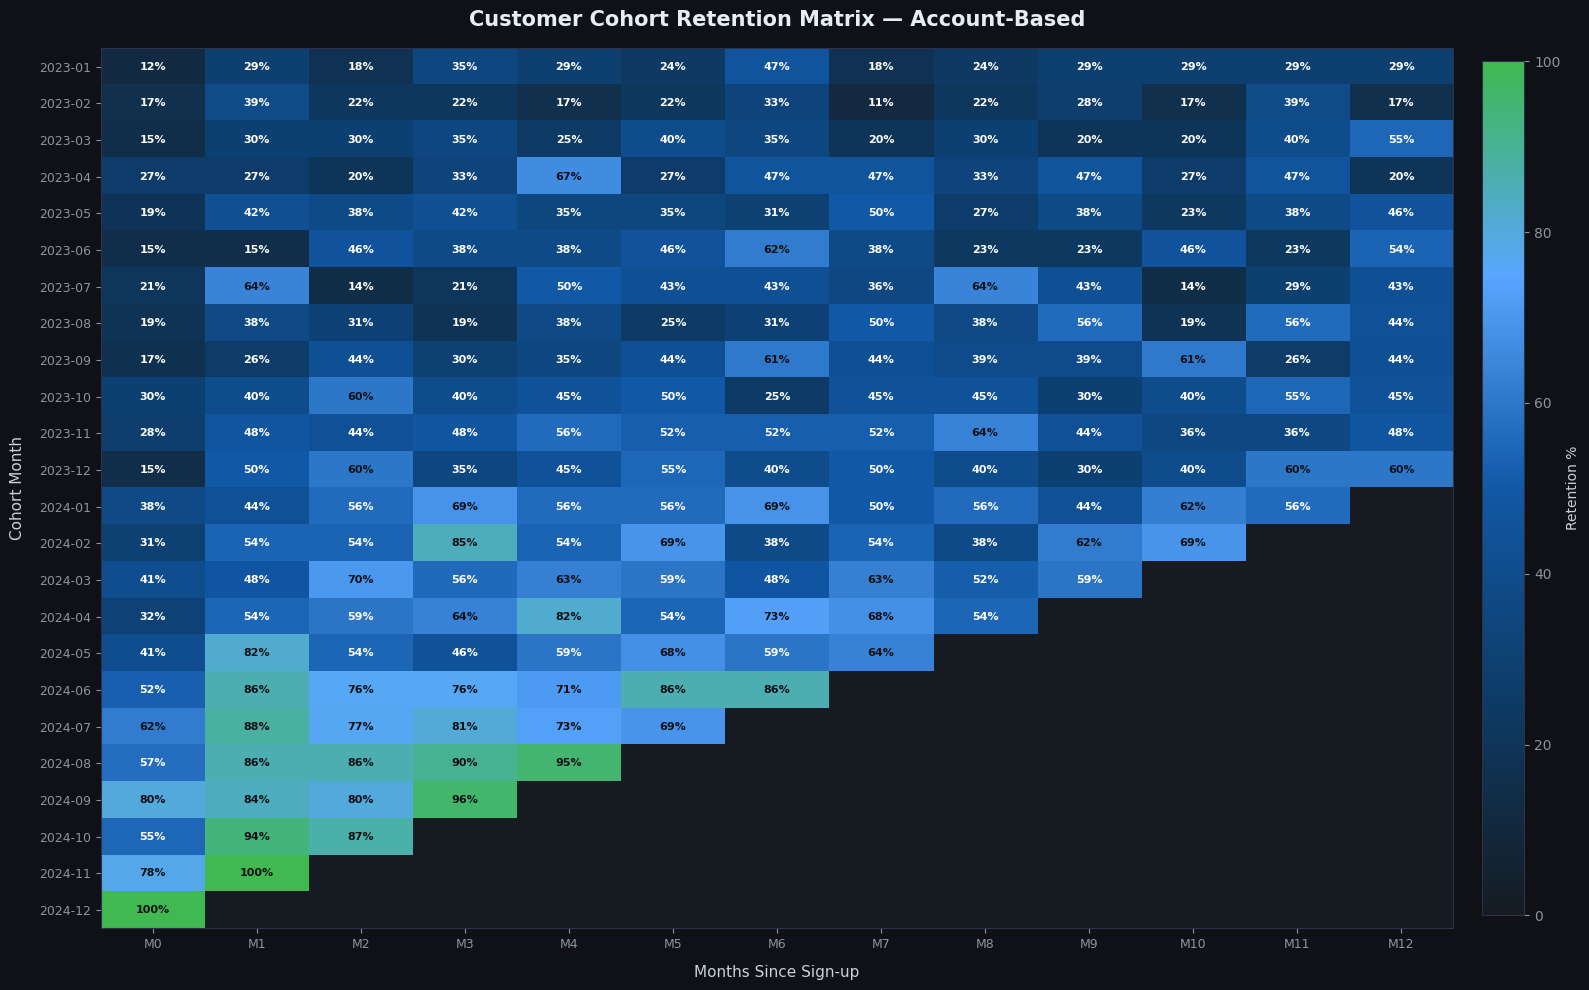

Saved: 06_cohort_retention_heatmap.png


In [24]:
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

cmap = mcolors.LinearSegmentedColormap.from_list(
    'retention_cmap',
    ['#161b22', '#0d3b66', '#1158a6', '#58a6ff', '#3fb950']
)

data_arr  = retention_pct.values
masked    = np.ma.masked_invalid(data_arr)
cmap.set_bad('#161b22')

im = ax.imshow(masked, cmap=cmap, aspect='auto', vmin=0, vmax=100)

for i in range(data_arr.shape[0]):
    for j in range(data_arr.shape[1]):
        val = data_arr[i, j]
        if not np.isnan(val):
            txt_color = 'white' if val < 60 else '#0f1117'
            ax.text(j, i, f'{val:.0f}%',
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color=txt_color)

ax.set_xticks(range(retention_pct.shape[1]))
ax.set_xticklabels([f'M{c}' for c in retention_pct.columns],
                    fontsize=9, color='#8b949e')
ax.set_yticks(range(retention_pct.shape[0]))
ax.set_yticklabels([str(p) for p in retention_pct.index],
                    fontsize=9, color='#8b949e')
ax.set_xlabel('Months Since Sign-up',  fontsize=11, color='#c9d1d9', labelpad=10)
ax.set_ylabel('Cohort Month',          fontsize=11, color='#c9d1d9', labelpad=10)
ax.set_title('Customer Cohort Retention Matrix — Account-Based',
              fontsize=15, fontweight='bold', color='#e6edf3', pad=16)


cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Retention %', color='#c9d1d9', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#8b949e')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/06_cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_cohort_retention_heatmap.png')

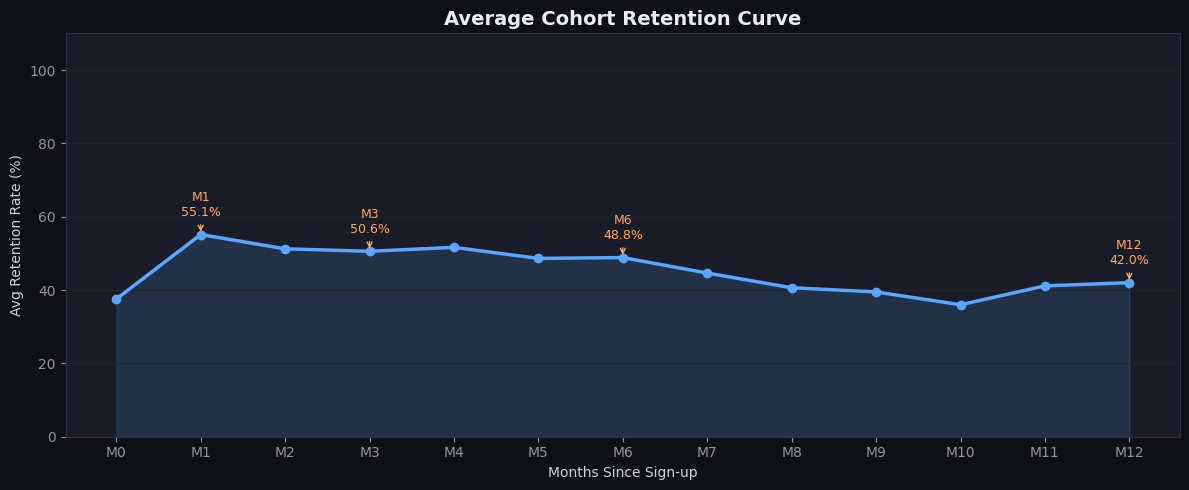

Saved: 07_avg_retention_curve.png


In [25]:
avg_retention = retention_pct.mean(axis=0).dropna()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(avg_retention.index, avg_retention.values,
        color='#58a6ff', linewidth=2.5, marker='o', markersize=6, zorder=3)
ax.fill_between(avg_retention.index, avg_retention.values,
                 alpha=0.15, color='#58a6ff')

for period in [1, 3, 6, 12]:
    if period in avg_retention.index:
        val = avg_retention[period]
        ax.annotate(
            f'M{period}\n{val:.1f}%',
            xy=(period, val), xytext=(period, val + 5),
            ha='center', fontsize=9, color='#ffa657',
            arrowprops=dict(arrowstyle='->', color='#ffa657', lw=1)
        )

ax.set_xticks(avg_retention.index)
ax.set_xticklabels([f'M{c}' for c in avg_retention.index])
ax.set_xlabel('Months Since Sign-up')
ax.set_ylabel('Avg Retention Rate (%)')
ax.set_ylim(0, 110)
ax.set_title('Average Cohort Retention Curve', fontsize=14, fontweight='bold', color='#e6edf3')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/07_avg_retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_avg_retention_curve.png')

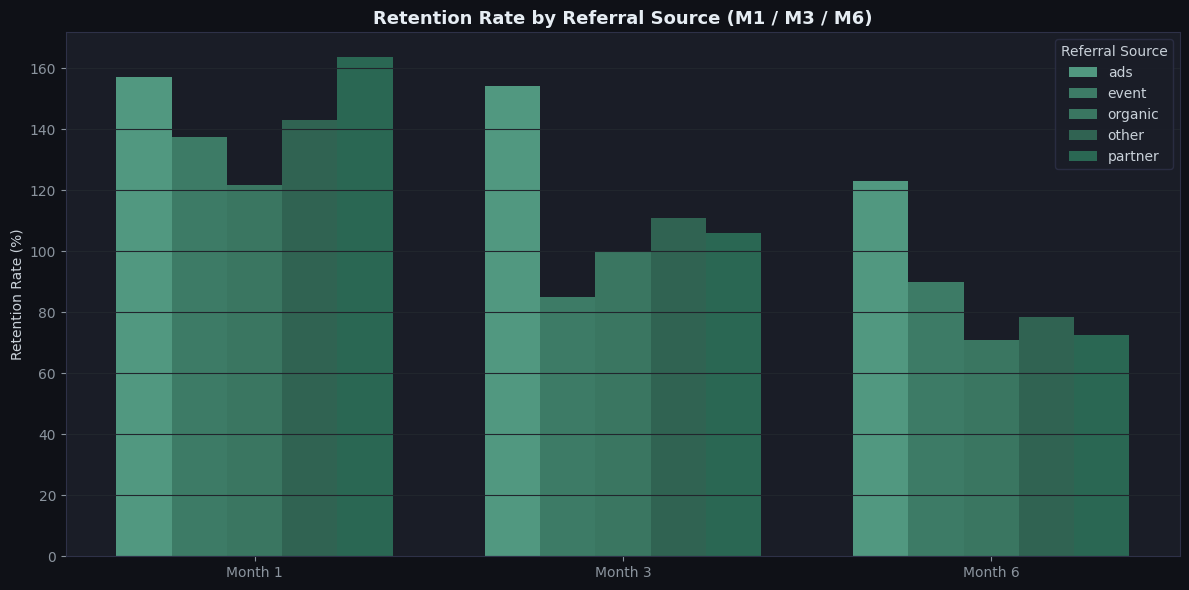

Saved: 08_retention_by_referral.png


In [26]:
cohort_ref = cohort_data.merge(
    accounts[['account_id', 'referral_source']],
    on='account_id',
    how='left'
)

ref_sizes = (
    cohort_ref[cohort_ref['period_number'] == 0]
    .groupby('referral_source')['account_id']
    .nunique()
)

ref_retained = (
    cohort_ref
    .groupby(['referral_source', 'period_number'])['account_id']
    .nunique()
    .reset_index()
)

ref_retained = ref_retained.merge(
    ref_sizes.rename('cohort_size'),
    on='referral_source'
)
ref_retained['retention_pct'] = (ref_retained['account_id'] /
                                   ref_retained['cohort_size'] * 100).round(1)

PALETTE = ["#5caf91", "#448d72", "#40866c", "#34705a", "#2d755b", "#1c4838"]
target_periods = [1, 3, 6]
plot_data = ref_retained[ref_retained['period_number'].isin(target_periods)]

fig, ax = plt.subplots(figsize=(12, 6))
sources = plot_data['referral_source'].unique()
x = np.arange(len(target_periods))
width = 0.15

for i, src in enumerate(sorted(sources)):
    src_data = plot_data[plot_data['referral_source'] == src].sort_values('period_number')
    ax.bar(x + i * width, src_data['retention_pct'],
           width=width, label=src, color=PALETTE[i % len(PALETTE)], alpha=0.85)

ax.set_xticks(x + width * (len(sources) - 1) / 2)
ax.set_xticklabels([f'Month {p}' for p in target_periods])
ax.set_ylabel('Retention Rate (%)')
ax.set_title('Retention Rate by Referral Source (M1 / M3 / M6)',
              fontsize=13, fontweight='bold', color='#e6edf3')
ax.legend(title='Referral Source', facecolor='#1a1d27',
           edgecolor='#2e3148', labelcolor='#c9d1d9')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/08_retention_by_referral.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_retention_by_referral.png')

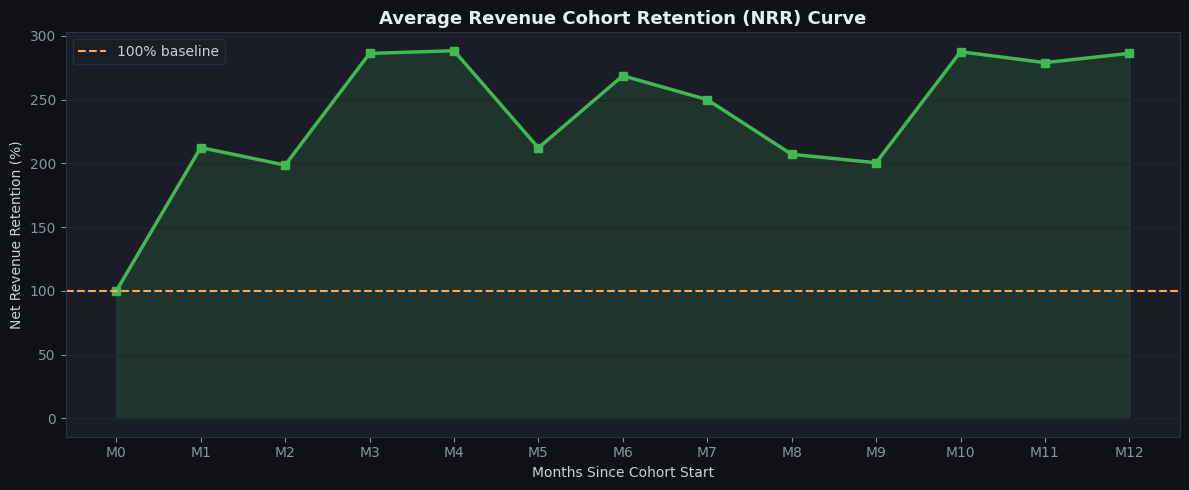

Saved: 09_nrr_curve.png


In [27]:
mrr_cohort = (
    cohort_data
    .groupby(['cohort_month', 'period_number'])['mrr_amount']
    .sum()
    .reset_index()
)

base_mrr = (
    mrr_cohort[mrr_cohort['period_number'] == 0]
    .set_index('cohort_month')['mrr_amount']
    .rename('base_mrr')
)

mrr_cohort = mrr_cohort.merge(base_mrr, on='cohort_month')
mrr_cohort['nrr_pct'] = (mrr_cohort['mrr_amount'] /
                          mrr_cohort['base_mrr'] * 100).round(1)

nrr_pivot = mrr_cohort.pivot(
    index='cohort_month', columns='period_number', values='nrr_pct'
)
nrr_pivot = nrr_pivot[[c for c in nrr_pivot.columns if 0 <= c <= 12]]

avg_nrr = nrr_pivot.mean(axis=0).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_nrr.index, avg_nrr.values,
        color='#3fb950', linewidth=2.5, marker='s', markersize=6)
ax.fill_between(avg_nrr.index, avg_nrr.values, alpha=0.15, color='#3fb950')
ax.axhline(100, color='#ffa657', linestyle='--', linewidth=1.5, label='100% baseline')
ax.set_xticks(avg_nrr.index)
ax.set_xticklabels([f'M{c}' for c in avg_nrr.index])
ax.set_xlabel('Months Since Cohort Start')
ax.set_ylabel('Net Revenue Retention (%)')
ax.set_title('Average Revenue Cohort Retention (NRR) Curve',
              fontsize=13, fontweight='bold', color='#e6edf3')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3148', labelcolor='#c9d1d9')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/09_nrr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_nrr_curve.png')

In [28]:
retention_pct.to_csv(f'{PROC_DIR}/cohort_retention_pct.csv')
nrr_pivot.to_csv(f'{PROC_DIR}/cohort_nrr_pct.csv')

print('Saved: cohort_retention_pct.csv')
print('Saved: cohort_nrr_pct.csv')

m1  = avg_retention.get(1,  float('nan'))
m3  = avg_retention.get(3,  float('nan'))
m6  = avg_retention.get(6,  float('nan'))
m12 = avg_retention.get(12, float('nan'))

print(f'\n=== RETENTION SUMMARY ===')
print(f'  Month-1  avg retention : {m1:.1f}%')
print(f'  Month-3  avg retention : {m3:.1f}%')
print(f'  Month-6  avg retention : {m6:.1f}%')
print(f'  Month-12 avg retention : {m12:.1f}%')

best_cohort  = retention_pct[6].idxmax()  if 6 in retention_pct.columns else 'N/A'
worst_cohort = retention_pct[6].idxmin()  if 6 in retention_pct.columns else 'N/A'
print(f'  Best  M6 retention cohort : {best_cohort}')
print(f'  Worst M6 retention cohort : {worst_cohort}')

Saved: cohort_retention_pct.csv
Saved: cohort_nrr_pct.csv

=== RETENTION SUMMARY ===
  Month-1  avg retention : 55.1%
  Month-3  avg retention : 50.6%
  Month-6  avg retention : 48.8%
  Month-12 avg retention : 42.0%
  Best  M6 retention cohort : 2024-06
  Worst M6 retention cohort : 2023-10
